Import Dependencies

In [1]:
from pydantic import BaseModel, Field
from langgraph.prebuilt import ToolNode
from langgraph.graph import StateGraph
from operator import add
from typing import Any, Annotated, Dict, List

from langchain_core.messages import BaseMessage, AIMessage, ToolMessage, HumanMessage, SystemMessage
from langchain_core.tools import BaseTool
from langchain_core.prompts import BasePromptTemplate
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.prompts import StringPromptTemplate
from langchain_core.prompts import PromptTemplate
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.messages import convert_to_openai_messages, convert_to_messages
from langchain_protocol import Literal

from jinja2 import Template
from typing import List, Dict, Any, Optional, Union
from IPython.display import Image, display
from operator import add
from openai import OpenAI

import random
import ast
import inspect
import instructor
import json

from utils import format_ai_message, parse_function_definition, get_type_from_annotation, parse_docstring_params, get_tool_descriptions

Single Node Graph

In [2]:
class State(BaseModel):
    message: str = Field(default="")
    answer: str = Field(default="")
    vibe: str = Field(default="")

In [3]:
def append_vibes_to_query(state: State) -> Dict:
  return {
    "answer": f"{state.message} {state.vibe}"
  }

In [4]:
workflow = StateGraph(State)
workflow.add_node("append_vibes_to_query", append_vibes_to_query)

workflow.add_edge("__start__", "append_vibes_to_query")
workflow.add_edge("append_vibes_to_query", "__end__")
graph = workflow.compile()

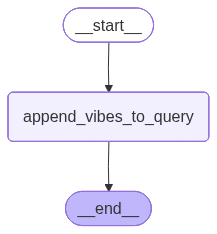

In [5]:
graph

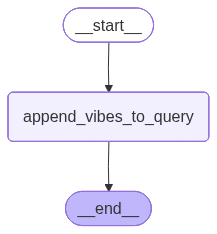

In [6]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [7]:
initial_state = {
    "message": "Give me some vibes!",
    "vibe": "I'm feeling like a badass today!"
}

In [8]:
result = graph.invoke(initial_state)

In [9]:
result

{'message': 'Give me some vibes!',
 'answer': "Give me some vibes! I'm feeling like a badass today!",
 'vibe': "I'm feeling like a badass today!"}

Conditional Graph

In [10]:
class State(BaseModel):
    message: str = Field(default="")
    answer: str = Field(default="")

In [11]:
def append_vibes_to_query(state: State) -> Dict:
  return {
    "answer": f"I am here to add some vibes!"
  }

In [12]:


def router(state: State) -> Literal["append_vibe_1", "append_vibe_2", "append_vibe_3"]:
    vibes = ["append_vibe_1", "append_vibe_2", "append_vibe_3"]
    vibe_path = random.choice(vibes)
    return vibe_path
    

In [13]:
def append_vibe_1(state: State) -> Dict:
    vibe = "I'm feeling like a badass today!"
    return {
        "answer": f"{state.message} {vibe}"
    }

In [14]:
def append_vibe_2(state: State) -> Dict:
    vibe = "I'm feeling like a boss today!"
    return {
        "answer": f"{state.message} {vibe}"
    }

In [15]:
def append_vibe_3(state: State) -> Dict:
    vibe = "I'm feeling like a legend today!"
    return {
        "answer": f"{state.message} {vibe}"
    }

In [16]:
workflow = StateGraph(State)

workflow.add_node("append_vibes_to_query", append_vibes_to_query)
workflow.add_node("append_vibe_1", append_vibe_1)
workflow.add_node("append_vibe_2", append_vibe_2)
workflow.add_node("append_vibe_3", append_vibe_3)

workflow.add_conditional_edges(
    "append_vibes_to_query", 
    router, 
    {
        "append_vibe_1": "append_vibe_1",
        "append_vibe_2": "append_vibe_2",
        "append_vibe_3": "append_vibe_3"
    }
)

workflow.add_edge("__start__", "append_vibes_to_query")
workflow.add_edge("append_vibe_1", "__end__")
workflow.add_edge("append_vibe_2", "__end__")
workflow.add_edge("append_vibe_3", "__end__")
# workflow.add_edge("append_vibes_to_query", "__end__")

graph = workflow.compile()

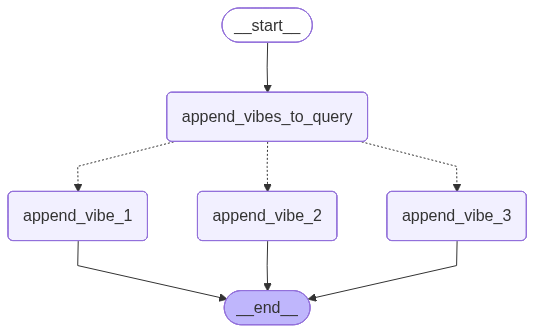

In [17]:
graph

In [18]:
initial_state = State(message="What is the weather like today?", vibe="in a happy tone")
result = graph.invoke(initial_state)

In [19]:
result

{'message': 'What is the weather like today?',
 'answer': "What is the weather like today? I'm feeling like a badass today!"}

Agent Graph

In [20]:
def append_vibes(query: str, vibe: str) -> str:
    """Takes in a query and a vibe and returns a string a string with the query and vibe appended together.
      Args:
        query: The query to append the vibe to.
        vibe: The vibe to append to the query.
    Returns:
        A string with the query and vibe appended together.
    """

    return f"{query} {vibe}"

In [21]:
get_tool_descriptions([append_vibes])

[{'name': 'append_vibes',
  'description': 'Takes in a query and a vibe and returns a string a string with the query and vibe appended together.\n  Args:\n    query: The query to append the vibe to.\n    vibe: The vibe to append to the query.\nReturns:\n    A string with the query and vibe appended together.',
  'parameters': {'type': 'object',
   'properties': {'query': {'type': 'string',
     'description': 'The query to append the vibe to.'},
    'vibe': {'type': 'string',
     'description': 'The vibe to append to the query.'}}},
  'required': ['query', 'vibe'],
  'returns': {'type': 'string',
   'description': 'A string with the query and vibe appended together.'}}]

In [22]:


class ToolCall(BaseModel):
    name: str
    args: Dict[str, Any]

class AgentResponse(BaseModel):
    answer: str
    tool_calls: List[ToolCall] = Field(default_factory=list)

class State(BaseModel):
    messages: Annotated[List[Any], add] = []
    message: str = Field(default="")
    iteration: int = Field(default=0)
    answer: str = Field(default="")
    available_tools: List[Dict[str, Any]] = []
    tools_calls: List[ToolCall] = []


In [23]:
def agent_node(state: "State") -> dict:
    prompt_template = f"""You are a assistant that is generating vibes for a user. You will be given a selection of tools you can use to add
     vibes to a user's query.
    <Available tools>
    {{available_tools | tojson}}
    </Available tools>
    
    When you need to use a tool, format your response as

    <tool_call>
    {"name": "tool_name", "args": {...}}
     </tool_call>

     Instructions:
     - You need to use the tools to add vibes to the user's query.
     - Add a random vibe to the user's query.

    """
    template = Template(prompt_template)
    prompt = template.render(
     available_tools = state.available_tools
    )

    client = instructor.from_openai(OpenAI())

    response = client.chat.completions.create_with_completion(
        model="gpt-4.1-mini",
        response_model = AgentResponse,
        messages = [{"role": "system", "content": prompt}, {"role": "user", "content": state.message}],
        temperature=0.7
    )

    ai_message = format_ai_message(response)
    return {
        "messages": [ai_message],
        "tools_calls": response.tool_calls
    }


short explainer on message types and formatting

In [24]:
conversation = [
    {
        "role": "user", "content": 'Give me some vibes!',
    },
    {
        "role": "assistant", "content": "I am here to add some vibes!"
    },
    {
        "role": "user", "content": "I am feeling like a badass today!"
    }
]

In [25]:
msg = convert_to_messages(conversation)

In [26]:
convert_to_openai_messages(msg)

[{'role': 'user', 'content': 'Give me some vibes!'},
 {'role': 'assistant', 'content': 'I am here to add some vibes!'},
 {'role': 'user', 'content': 'I am feeling like a badass today!'}]

In [27]:
dummy_response = AgentResponse(
    answer="I am here to add some vibes!",
    tool_calls=[
        ToolCall(name="append_vibes", args={"query": "Give me some vibes!", "vibe": "I'm feeling like a badass today!"})
    ],
)

In [28]:
dummy_response

AgentResponse(answer='I am here to add some vibes!', tool_calls=[ToolCall(name='append_vibes', args={'query': 'Give me some vibes!', 'vibe': "I'm feeling like a badass today!"})])

In [29]:
# def format_ai_message(response):
#     if response.tool_calls:
#         tool_calls = []
#         for i, tc in enumerate(response.tool_calls):
#             tool_args = getattr(tc, "args", None)
#             if tool_args is None:
#                 tool_args = getattr(tc, "arguments", {})

#             tool_calls.append({
#                "id": f"call_{i}",
#                "name": tc.name,
#                "args": tool_args
#             })

#         ai_message = AIMessage(
#             content=response.answer,
#             tool_calls=tool_calls
#         )
#     else:
#         ai_message = AIMessage(content=response.answer)
    
#     return ai_message

In [31]:
format_ai_message(dummy_response)

AIMessage(content='I am here to add some vibes!', additional_kwargs={}, response_metadata={}, tool_calls=[{'name': 'append_vibes', 'args': {'query': 'Give me some vibes!', 'vibe': "I'm feeling like a badass today!"}, 'id': 'call_0', 'type': 'tool_call'}], invalid_tool_calls=[])

End a Short explainer on message types and formatting

In [34]:
def tool_router(state: State) -> str:
    """Decide whether to continue or end """
    if len[state.tools_calls] > 0:
        return "tools"
    else:
        return "end"

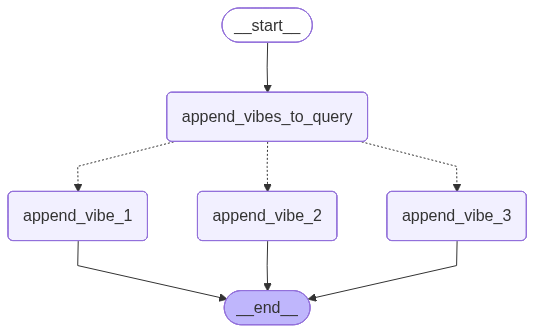

In [35]:
workflow = StateGraph(State)
workflow.add_node("append_vibes_to_query", append_vibes_to_query)
workflow.add_node("append_vibe_1", append_vibe_1)
workflow.add_node("append_vibe_2", append_vibe_2)
workflow.add_node("append_vibe_3", append_vibe_3)

workflow.add_conditional_edges(
    "append_vibes_to_query", 
    tool_router,
    {
        "append_vibe_1": "append_vibe_1",
        "append_vibe_2": "append_vibe_2",
        "append_vibe_3": "append_vibe_3",
    }
)

workflow.add_edge("__start__", "append_vibes_to_query")
workflow.add_edge("append_vibe_1", "__end__")
workflow.add_edge("append_vibe_2", "__end__")   
workflow.add_edge("append_vibe_3", "__end__")

graph = workflow.compile()
graph

In [ ]:
workflow = StateGraph(State)
tools = [append_vibes]
tool_node = ToolNode(tools=tools)

workflow.add_node("agent_node", agent_node)

workflow.add_conditional_edges(
    "append_vibes_to_query", 
    tool_router,
    {
        "append_vibe_1": "append_vibe_1",
        "append_vibe_2": "append_vibe_2",
        "append_vibe_3": "append_vibe_3",
    }
)

workflow.add_edge("__start__", "append_vibes_to_query")
workflow.add_edge("append_vibe_1", "__end__")
workflow.add_edge("append_vibe_2", "__end__")   
workflow.add_edge("append_vibe_3", "__end__")

graph = workflow.compile()
graph